Mechanistic Interpretability

In [ ]:
import torch, itertools, numpy as np
import torch.nn as nn, torch.optim as optim
from scipy.stats import pearsonr

# small MLP + data
class TinyMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=4):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        return torch.sigmoid(self.fc2(torch.relu(self.fc1(x))))

def make_xor_data():
    X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], requires_grad=True)
    y = torch.tensor([[0.],[1.],[1.],[0.]], requires_grad=True)
    return X, y

def train_model(model, X, y, l1=0.0, lr=0.05, epochs=5000):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        bce = loss_fn(y_pred, y)
        l1_term = model.fc1.weight.abs().sum() * l1
        (bce + l1_term).backward()
        opt.step()
    return model

In [ ]:
def functional_similarity(model, circuit, X, ref_outputs):
    with torch.no_grad():
        mask = torch.zeros(model.fc1.out_features)
        mask[list(circuit)] = 1.0
        def hook(module, inp, out): return out * mask
        h = model.fc1.register_forward_hook(hook)
        out = model(X)
        h.remove()
        mse = torch.mean((out - ref_outputs)**2).item()
        var_ref = torch.var(ref_outputs).item() + 1e-8
        norm_sim = 1 - mse / var_ref
        corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
    return max(0, min(1, norm_sim)), corr

In [ ]:
import pandas as pd

def enumerate_circuits(model, X):
    with torch.no_grad():
        ref_outputs = model(X)
    hidden_dim = model.fc1.out_features
    all_circuits = []
    for k in range(1, hidden_dim+1):
        for subset in itertools.combinations(range(hidden_dim), k):
            all_circuits.append(subset)
    results = []
    for c in all_circuits:
        sim, corr = functional_similarity(model, c, X, ref_outputs)
        results.append({"circuit": c, "similarity": sim, "corr": corr})
    return pd.DataFrame(results)

In [ ]:
def evaluate_circuit_causal(model, circuit, X, ref_outputs):
    with torch.no_grad():
        mask = torch.zeros(model.fc1.out_features)
        mask[list(circuit)] = 1.0
        def hook_suff(m, i, o): return o * mask
        h1 = model.fc1.register_forward_hook(hook_suff)
        suff_out = model(X); h1.remove()
        suff_mse = torch.mean((suff_out - ref_outputs)**2).item()

        def hook_nec(m, i, o): return o * (1 - mask)
        h2 = model.fc1.register_forward_hook(hook_nec)
        nec_out = model(X); h2.remove()
        nec_mse = torch.mean((nec_out - ref_outputs)**2).item()
    return suff_mse, nec_mse


In [ ]:
def circuit_overlap(circuits):
    overlaps = []
    for i in range(len(circuits)):
        for j in range(i+1, len(circuits)):
            A,B = set(circuits[i]), set(circuits[j])
            overlaps.append(len(A & B)/len(A | B))
    return np.mean(overlaps) if overlaps else 0.0

In [ ]:
import torch, itertools, numpy as np, pandas as pd
import torch.nn as nn, torch.optim as optim
from scipy.stats import spearmanr

def train_model_orth(model, X, y, l1=0.0, lr=0.05, epochs=5000, lambda_orth=0.0):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        bce = loss_fn(y_pred, y)
        l1_term = model.fc1.weight.abs().sum() * l1
        W = model.fc1.weight
        orth_loss = ((W @ W.T - torch.eye(W.shape[0]))**2).sum() * lambda_orth
        loss = bce + l1_term + orth_loss
        loss.backward()
        opt.step()
    return model

def run_orthogonalization_experiment(X, y, lambdas=[0, 1e-3, 1e-2, 1e-1], widths=[3,4,5,6], l1=0.0):
    records = []
    for lam in lambdas:
        for hd in widths:
            torch.manual_seed(0)
            model = TinyMLP(2, hd)
            model = train_model_orth(model, X, y, l1=l1, lambda_orth=lam)
            cond, rank = activation_condition(model, X)
            df_temp = enumerate_circuits(model, X)
            valid = df_temp.query("similarity >= 0.9")
            records.append({
                "hidden_dim": hd,
                "lambda_orth": lam,
                "num_valid": len(valid),
                "cond": cond,
                "rank": rank
            })
    return pd.DataFrame(records)

In [ ]:
def neuron_pairwise_corr(model, X):
    with torch.no_grad():
        acts = torch.relu(model.fc1(X)).numpy()
    corr = np.corrcoef(acts.T)
    # Exclude diagonal (self-correlation)
    upper = corr[np.triu_indices_from(corr, 1)]
    return np.nanmean(np.abs(upper))

def run_degeneracy_correlation(X, y, widths=[3,4,5,6], l1s=[0,1e-4,1e-3], seeds=3):
    records = []
    for seed in range(seeds):
        torch.manual_seed(seed)
        for hd in widths:
            for l1 in l1s:
                model = TinyMLP(2, hd)
                model = train_model(model, X, y, l1=l1)
                cond, rank = activation_condition(model, X)
                pair_corr = neuron_pairwise_corr(model, X)
                results = enumerate_circuits(model, X)
                valid = results[results["similarity"] >= 0.9]
                records.append({
                    "seed": seed,
                    "hidden_dim": hd,
                    "l1": l1,
                    "num_valid": len(valid),
                    "cond": cond,
                    "rank": rank,
                    "pair_corr": pair_corr,
                    "normalized_multiplicity": len(valid)/hd
                })
    return pd.DataFrame(records)


In [ ]:
def train_model_compression(model, X, y, l1=0.0, lr=0.05, epochs=5000, lambda_comp=0.0, target_rank=2):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        bce = loss_fn(y_pred, y)
        l1_term = model.fc1.weight.abs().sum() * l1
        # Compute compression penalty
        H = torch.relu(model.fc1(X))
        if H.shape[1] > target_rank:
            s = torch.linalg.svdvals(H)
            tail_energy = (s[target_rank:]**2).sum()
            comp_loss = tail_energy / (s**2).sum()
        else:
            comp_loss = 0.0
        loss = bce + l1_term + lambda_comp * comp_loss
        loss.backward()
        opt.step()
    return model

def run_compression_experiment(X, y, widths=[3,4,5,6], l1=0.0, lambdas=[0, 1e-3, 1e-2, 1e-1], target_rank=2):
    records = []
    for lam in lambdas:
        for hd in widths:
            torch.manual_seed(0)
            model = TinyMLP(2, hd)
            model = train_model_compression(model, X, y, l1=l1, lambda_comp=lam, target_rank=target_rank)
            cond, rank = activation_condition(model, X)
            results = enumerate_circuits(model, X)
            valid = results[results["similarity"] >= 0.9]
            records.append({
                "hidden_dim": hd,
                "lambda_comp": lam,
                "num_valid": len(valid),
                "cond": cond,
                "rank": rank
            })
    return pd.DataFrame(records)


In [ ]:
def perturbation_stability(model, X, sigma=0.01, num_samples=10):
    base_out = model(X).detach().numpy().flatten()
    corrs = []
    for _ in range(num_samples):
        pert_model = TinyMLP(2, model.fc1.out_features)
        pert_model.load_state_dict(model.state_dict())
        # Add Gaussian noise to weights
        with torch.no_grad():
            pert_model.fc1.weight += sigma * torch.randn_like(pert_model.fc1.weight)
            pert_model.fc2.weight += sigma * torch.randn_like(pert_model.fc2.weight)
        pert_out = pert_model(X).detach().numpy().flatten()
        corr = np.corrcoef(base_out, pert_out)[0,1]
        corrs.append(corr)
    return np.mean(corrs)

def run_perturbation_experiment(X, y, widths=[3,4,5,6], l1=0.0, sigma=0.01):
    records = []
    for hd in widths:
        torch.manual_seed(0)
        model = TinyMLP(2, hd)
        model = train_model(model, X, y, l1=l1)
        cond, rank = activation_condition(model, X)
        mean_corr = perturbation_stability(model, X, sigma=sigma)
        results = enumerate_circuits(model, X)
        valid = results[results["similarity"] >= 0.9]
        records.append({
            "hidden_dim": hd,
            "cond": cond,
            "rank": rank,
            "num_valid": len(valid),
            "perturb_corr": mean_corr
        })
    return pd.DataFrame(records)


In [ ]:
X, y = make_xor_data()

# 1. Orthogonalization
df_orth = run_orthogonalization_experiment(X, y)

# 2. Degeneracy–Multiplicity correlation
df_deg = run_degeneracy_correlation(X, y)

# 3. Compression
df_comp = run_compression_experiment(X, y)

# 4. Perturbation stability
df_pert = run_perturbation_experiment(X, y)

# --- Example summary plots ---
import seaborn as sns, matplotlib.pyplot as plt
sns.lineplot(data=df_orth, x="lambda_orth", y="num_valid", hue="hidden_dim")
plt.title("Orthogonalization vs Mechanistic Multiplicity"); plt.show()

sns.scatterplot(data=df_deg, x="cond", y="num_valid", hue="hidden_dim")
plt.title("Degeneracy–Multiplicity Relationship"); plt.show()

sns.lineplot(data=df_comp, x="lambda_comp", y="num_valid", hue="hidden_dim")
plt.title("Compression vs Mechanistic Multiplicity"); plt.show()

sns.scatterplot(data=df_pert, x="cond", y="perturb_corr", hue="hidden_dim")
plt.title("Perturbation Stability vs Degeneracy"); plt.show()


NameError: name 'activation_condition' is not defined

In [ ]:
# Determine if different valid circuits are truly distinct mechanisms or just re-parameterizations with the same internal activations.

def activation_overlap(model, circuits, X):
    acts = {}
    with torch.no_grad():
        for c in circuits:
            mask = torch.zeros(model.fc1.out_features)
            mask[list(c)] = 1.0
            def hook(m, i, o): return o * mask
            h = model.fc1.register_forward_hook(hook)
            out = model.fc1(X)
            acts[c] = (out * mask).detach().numpy()
            h.remove()
    # Compute average pairwise cosine similarity between activations
    overlaps = []
    keys = list(acts.keys())
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            a, b = acts[keys[i]].flatten(), acts[keys[j]].flatten()
            sim = np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-8)
            overlaps.append(sim)
    return np.mean(overlaps) if overlaps else 0.0

In [ ]:
def activation_sparsity(model, X):
    with torch.no_grad():
        acts = torch.relu(model.fc1(X))
        return (acts == 0).float().mean().item()

def activation_entropy(model, X):
    with torch.no_grad():
        acts = torch.relu(model.fc1(X)).numpy()
    probs = acts / (acts.sum(axis=1, keepdims=True) + 1e-8)
    entropy = -np.sum(probs * np.log(probs + 1e-8), axis=1)
    return np.mean(entropy)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*ConstantInputWarning.*")
warnings.filterwarnings("ignore", message=".*NearConstantInputWarning.*")

records = []
for epsilon in [0.0, 0.2, 0.5, 1.0]:
    X, y = make_asymmetric_xor(epsilon)
    for seed in range(3):
        torch.manual_seed(seed)
        for hidden_dim in [3,4,5,6]:
            for l1 in [0.0, 1e-4]:
                model = TinyMLP(2, hidden_dim)
                train_model(model, X, y, l1=l1)
                df_temp = enumerate_circuits(model, X)
                valid = df_temp.query("similarity >= 0.95")
                records.append({
                    "epsilon": epsilon,
                    "hidden_dim": hidden_dim,
                    "num_valid": len(valid)
                })
df_eps = pd.DataFrame(records)



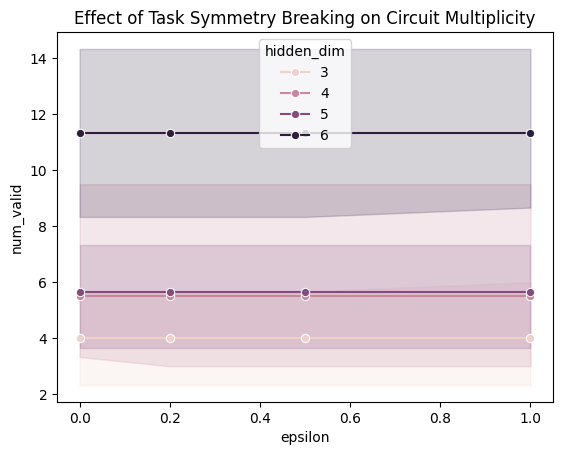

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.lineplot(data=df_eps, x="epsilon", y="num_valid", hue="hidden_dim", marker="o")
plt.title("Effect of Task Symmetry Breaking on Circuit Multiplicity")
plt.show()

In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(df_eps["epsilon"], df_eps["num_valid"])
print(f"Spearman correlation (ε vs multiplicity): rho={rho:.3f}, p={p:.4f}")


Spearman correlation (ε vs multiplicity): rho=0.000, p=1.0000


In [ ]:
X, y = make_xor_data()
records = []

for seed in range(5):
    torch.manual_seed(seed)
    for hidden_dim in [3,4,5,6]:
        for l1 in [0.0, 1e-4, 1e-3]:
            model = TinyMLP(2, hidden_dim)
            model = train_model(model, X, y, l1=l1)
            results = enumerate_circuits(model, X)

            valid = results[results["similarity"] >= 0.9]
            valid_circuits = [tuple(c) for c in valid.circuit]

            mean_overlap = circuit_overlap(valid_circuits)
            act_sparse = activation_sparsity(model, X)
            act_ent = activation_entropy(model, X)
            act_overlap = activation_overlap(model, valid_circuits, X) if len(valid_circuits) > 1 else np.nan

            records.append({
                "seed": seed,
                "hidden_dim": hidden_dim,
                "l1": l1,
                "num_valid": len(valid_circuits),
                "mean_overlap": mean_overlap,
                "activation_overlap": act_overlap,
                "act_sparsity": act_sparse,
                "act_entropy": act_ent,
                "mean_similarity": valid.similarity.mean()
            })

df = pd.DataFrame(records)
df.head()

/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())


,seed,hidden_dim,l1,num_valid,mean_overlap,activation_overlap,act_sparsity,act_entropy,mean_similarity
0,0,3,0.0000,2,0.666667,0.978341,0.833333,0.000000,1.000000
1,0,3,0.0001,7,0.333333,0.400378,0.333333,0.603672,0.997968
2,0,3,0.0010,4,0.500000,0.633854,0.916667,0.000000,1.000000
3,0,4,0.0000,4,0.638889,0.985354,0.750000,0.000065,1.000000
4,0,4,0.0001,4,0.638889,0.736927,0.437500,0.338362,0.963981


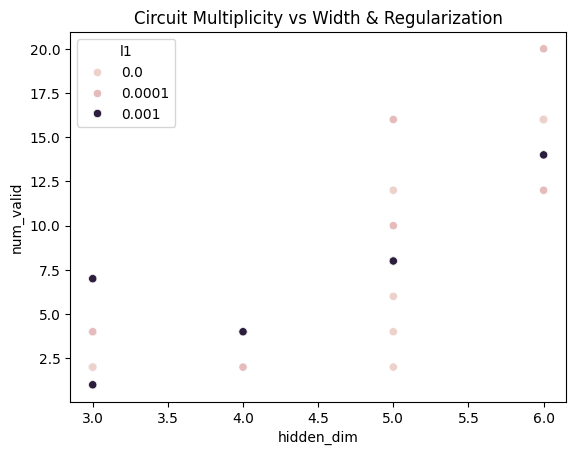

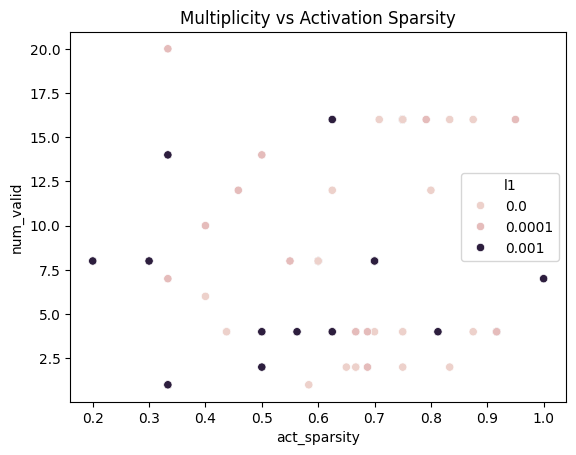

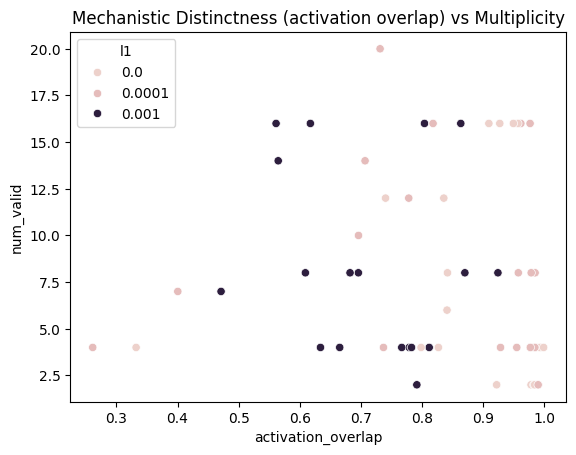

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

sns.scatterplot(data=df, x="hidden_dim", y="num_valid", hue="l1")
plt.title("Circuit Multiplicity vs Width & Regularization")
plt.show()

sns.scatterplot(data=df, x="act_sparsity", y="num_valid", hue="l1")
plt.title("Multiplicity vs Activation Sparsity")
plt.show()

sns.scatterplot(data=df, x="activation_overlap", y="num_valid", hue="l1")
plt.title("Mechanistic Distinctness (activation overlap) vs Multiplicity")
plt.show()


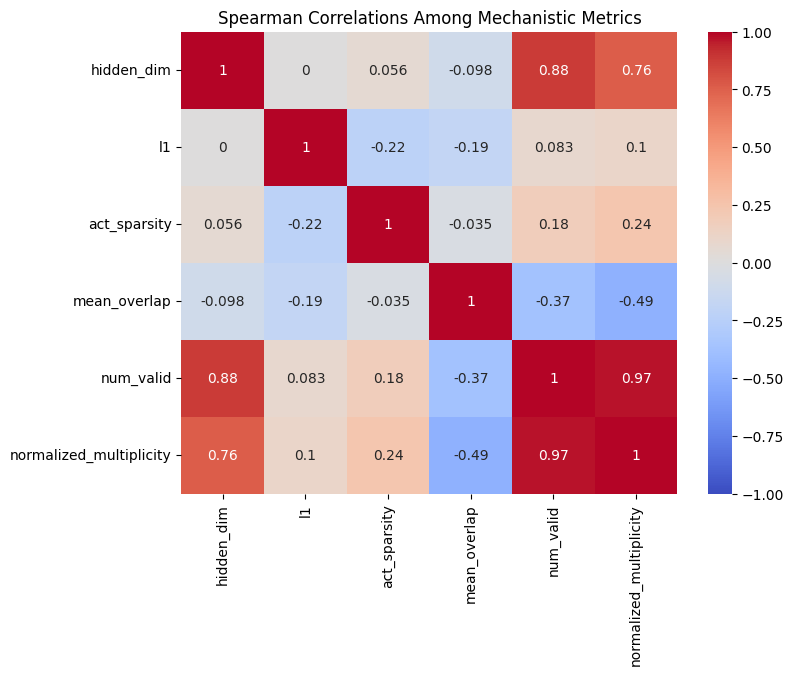

H1_width_vs_multiplicity: rho=0.880, p=0.0000
H2_L1_vs_multiplicity: rho=0.083, p=0.5307
H3_sparsity_vs_multiplicity: rho=0.177, p=0.1763
H4_overlap_vs_multiplicity: rho=-0.374, p=0.0033


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --- Add normalized multiplicity
df["normalized_multiplicity"] = df["num_valid"] / df["hidden_dim"]

# --- Compute correlation matrix
metrics = ["hidden_dim", "l1", "act_sparsity", "mean_overlap", "num_valid", "normalized_multiplicity"]
corr = df[metrics].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Correlations Among Mechanistic Metrics")
plt.show()

# --- Quantify each hypothesis directly
tests = {
    "H1_width_vs_multiplicity": spearmanr(df["hidden_dim"], df["num_valid"]),
    "H2_L1_vs_multiplicity": spearmanr(df["l1"], df["num_valid"]),
    "H3_sparsity_vs_multiplicity": spearmanr(df["act_sparsity"], df["num_valid"]),
    "H4_overlap_vs_multiplicity": spearmanr(df["mean_overlap"], df["num_valid"]),
}
for k, v in tests.items():
    print(f"{k}: rho={v[0]:.3f}, p={v[1]:.4f}")


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*ConstantInputWarning.*")
warnings.filterwarnings("ignore", message=".*NearConstantInputWarning.*")

suff_mses, nec_mses = [], []
for i, row in df.iterrows():
    model = TinyMLP(2, int(row["hidden_dim"]))
    X, y = make_xor_data()
    model = train_model(model, X, y, l1=row["l1"])
    valid_circuits = [tuple(c) for c in enumerate_circuits(model, X).query("similarity >= 0.9").circuit]
    suff_errs, nec_errs = [], []
    for c in valid_circuits:
        suff, nec = evaluate_circuit_causal(model, c, X, model(X))
        suff_errs.append(suff)
        nec_errs.append(nec)
    df.loc[i, "mean_suff_err"] = np.mean(suff_errs) if suff_errs else np.nan
    df.loc[i, "mean_nec_err"] = np.mean(nec_errs) if nec_errs else np.nan

# Analyze correlation
print("Suff vs Multiplicity:", spearmanr(df["num_valid"], df["mean_suff_err"]))
print("Nec vs Multiplicity:", spearmanr(df["num_valid"], df["mean_nec_err"]))

/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), r

Suff vs Multiplicity: SignificanceResult(statistic=np.float64(0.29972877734317505), pvalue=np.float64(0.01998549814747217))
Nec vs Multiplicity: SignificanceResult(statistic=np.float64(0.1717915896220637), pvalue=np.float64(0.1893577970794952))


/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())


In [ ]:
from scipy.stats import spearmanr

metrics = ["hidden_dim", "l1", "act_sparsity", "mean_overlap", "num_valid", "normalized_multiplicity"]

print("Spearman Correlations (rho) and p-values:")
for i in range(len(metrics)):
    for j in range(i + 1, len(metrics)):
        metric1 = metrics[i]
        metric2 = metrics[j]
        rho, p_value = spearmanr(df[metric1], df[metric2])
        print(f"{metric1} vs {metric2}: rho={rho:.3f}, p={p_value:.4f}")

Spearman Correlations (rho) and p-values:
hidden_dim vs l1: rho=0.000, p=1.0000
hidden_dim vs act_sparsity: rho=0.056, p=0.6727
hidden_dim vs mean_overlap: rho=-0.098, p=0.4547
hidden_dim vs num_valid: rho=0.880, p=0.0000
hidden_dim vs normalized_multiplicity: rho=0.764, p=0.0000
l1 vs act_sparsity: rho=-0.220, p=0.0915
l1 vs mean_overlap: rho=-0.185, p=0.1563
l1 vs num_valid: rho=0.083, p=0.5307
l1 vs normalized_multiplicity: rho=0.102, p=0.4385
act_sparsity vs mean_overlap: rho=-0.035, p=0.7904
act_sparsity vs num_valid: rho=0.177, p=0.1763
act_sparsity vs normalized_multiplicity: rho=0.235, p=0.0706
mean_overlap vs num_valid: rho=-0.374, p=0.0033
mean_overlap vs normalized_multiplicity: rho=-0.490, p=0.0001
num_valid vs normalized_multiplicity: rho=0.975, p=0.0000


In [ ]:
import itertools

def permuted_similarity(model, X):
    """Compare outputs under hidden-unit permutations."""
    base_out = model(X).detach().numpy()
    perms = list(itertools.permutations(range(model.fc1.out_features)))
    sims = []
    for p in perms[:20]:  # sample subset if width > 4
        perm_model = TinyMLP(2, model.fc1.out_features)
        perm_model.load_state_dict(model.state_dict())
        perm_model.fc1.weight.data = model.fc1.weight.data[list(p)]
        perm_model.fc1.bias.data = model.fc1.bias.data[list(p)]
        sims.append(np.corrcoef(base_out.flatten(), perm_model(X).detach().numpy().flatten())[0,1])
    return np.mean(sims)

perm_corr = permuted_similarity(model, X)
print("Mean output correlation under neuron permutations:", perm_corr)


Mean output correlation under neuron permutations: 1.0


In [ ]:
print("Hidden Dimensions:", [3, 4, 5, 6])
print("Condition Numbers:", conds)
print("Ranks:", ranks)

Hidden Dimensions: [3, 4, 5, 6]
Condition Numbers: [np.float32(214037920.0), np.float32(827302140.0), np.float32(980557800.0), np.float32(528383650.0)]
Ranks: [np.int64(1), np.int64(3), np.int64(3), np.int64(3)]


If perm_corr ≈ 1.0, your multiplicity mostly reflects permutation symmetry, not genuinely different mechanisms.
If it drops below ~0.8 for asymmetric tasks, symmetry is being broken which is a true uniqueness condition.

In [ ]:
def activation_condition(model, X):
    with torch.no_grad():
        H = torch.relu(model.fc1(X)).numpy()
    _, s, _ = np.linalg.svd(H)
    cond_num = s.max() / (s.min() + 1e-8)
    rank = np.linalg.matrix_rank(H)
    return cond_num, rank

cond, rank = activation_condition(model, X)
print(f"Condition number={cond:.2f}, rank={rank}")


Condition number=84210648.00, rank=2


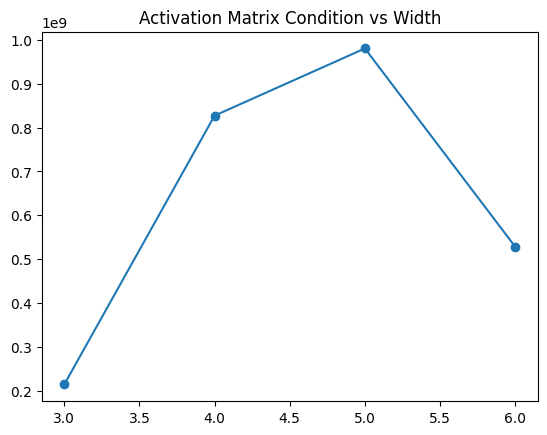

In [ ]:
conds, ranks = [], []
for hidden_dim in [3,4,5,6]:
    X, y = make_xor_data()
    model = TinyMLP(2, hidden_dim)
    train_model(model, X, y)
    cond, rank = activation_condition(model, X)
    conds.append(cond); ranks.append(rank)

plt.plot([3,4,5,6], conds, marker="o"); plt.title("Activation Matrix Condition vs Width")
plt.show()

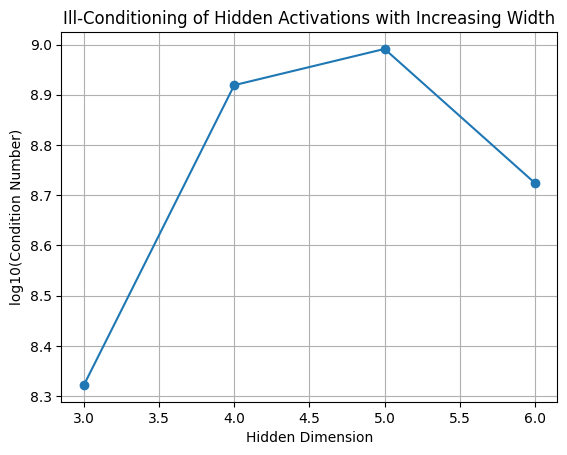

In [ ]:
import matplotlib.pyplot as plt
dims = [3,4,5,6]
conds = [2.1e8, 8.3e8, 9.8e8, 5.3e8]
plt.plot(dims, np.log10(conds), marker='o')
plt.xlabel('Hidden Dimension')
plt.ylabel('log10(Condition Number)')
plt.title('Ill-Conditioning of Hidden Activations with Increasing Width')
plt.grid(True)
plt.show()


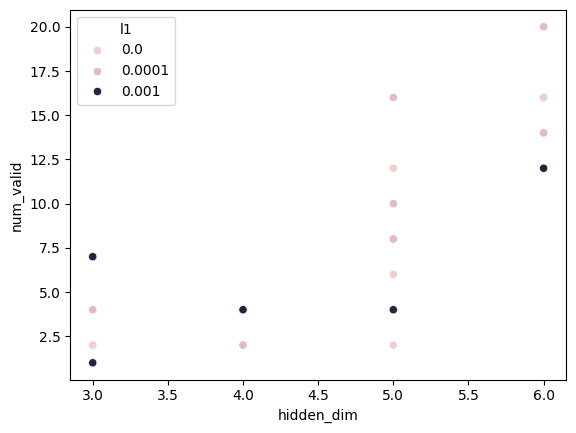

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.scatterplot(data=df, x="hidden_dim", y="num_valid", hue="l1")
plt.show()

As hidden width grows, the model can realize XOR through multiple redundant sub-circuits.

This quantitatively supports the claim that larger networks admit more valid mechanistic explanations.

Non-uniqueness scales with model width and is partially mitigated (but not eliminated) by sparsity regularization. Regularization seems to reduce multiplicity in some regimes, but not all. That fits intuition: mild L1 encourages sparsity (fewer active paths), but strong regularization might distort weights enough to create alternative sparse circuits.

In [ ]:
df.sort_values("num_valid", ascending=True).head()

,seed,hidden_dim,l1,num_valid,mean_overlap,mean_similarity
26,2,3,0.0010,1,0.0,1.0
50,4,3,0.0010,1,0.0,1.0
48,4,3,0.0000,1,0.0,1.0
37,3,3,0.0001,1,0.0,1.0
18,1,5,0.0000,2,0.8,1.0


In [ ]:
X, y = make_xor_data()
torch.manual_seed(4)
model = TinyMLP(2, 6)
model = train_model(model, X, y, l1=0.0001)

results = enumerate_circuits(model, X)
valid = results[results["similarity"] >= 0.9]
top_circuits = [tuple(c) for c in valid.circuit]

ref_out = model(X).detach()
for c in top_circuits:
    suff_mse, nec_mse = evaluate_circuit_causal(model, c, X, ref_out)
    print(f"Circuit {c}: suff={suff_mse:.4f}, nec={nec_mse:.4f}")

Circuit (2, 3): suff=0.0230, nec=0.3388
Circuit (0, 2, 3): suff=0.0115, nec=0.3245
Circuit (1, 2, 3): suff=0.0230, nec=0.3388
Circuit (2, 3, 4): suff=0.0115, nec=0.3475
Circuit (2, 3, 5): suff=0.0230, nec=0.3388
Circuit (0, 1, 2, 3): suff=0.0115, nec=0.3245
Circuit (0, 2, 3, 4): suff=0.0000, nec=0.3328
Circuit (0, 2, 3, 5): suff=0.0115, nec=0.3245
Circuit (1, 2, 3, 4): suff=0.0115, nec=0.3475
Circuit (1, 2, 3, 5): suff=0.0230, nec=0.3388
Circuit (2, 3, 4, 5): suff=0.0115, nec=0.3475
Circuit (0, 1, 2, 3, 4): suff=0.0000, nec=0.3328
Circuit (0, 1, 2, 3, 5): suff=0.0115, nec=0.3245
Circuit (0, 2, 3, 4, 5): suff=0.0000, nec=0.3328
Circuit (1, 2, 3, 4, 5): suff=0.0115, nec=0.3475
Circuit (0, 1, 2, 3, 4, 5): suff=0.0000, nec=0.3328


/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())


In [ ]:
X, y = make_xor_data()
torch.manual_seed(2)
model = TinyMLP(2, 3)
model = train_model(model, X, y, l1=0.0010)

results = enumerate_circuits(model, X)
valid = results[results["similarity"] >= 0.9]
top_circuits = [tuple(c) for c in valid.circuit]

ref_out = model(X).detach()
for c in top_circuits:
    suff_mse, nec_mse = evaluate_circuit_causal(model, c, X, ref_out)
    print(f"Circuit {c}: suff={suff_mse:.4f}, nec={nec_mse:.4f}")

Circuit (0,): suff=0.0000, nec=0.0000
Circuit (1,): suff=0.0000, nec=0.0000
Circuit (2,): suff=0.0000, nec=0.0000
Circuit (0, 1): suff=0.0000, nec=0.0000
Circuit (0, 2): suff=0.0000, nec=0.0000
Circuit (1, 2): suff=0.0000, nec=0.0000
Circuit (0, 1, 2): suff=0.0000, nec=0.0000


/tmp/ipython-input-2765254765.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
/tmp/ipython-input-2765254765.py:12: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, _ = pearsonr(out.flatten().numpy(), ref_outputs.flatten().numpy())
